# Audio Data — Exploratory Data Analysis

Explores the processed Vaani Hindi audio dataset across two districts:
**MadhyaPradesh_Bhopal** and **UttarPradesh_Lucknow**.

Sections:
1. Load manifests & basic statistics
2. Duration distributions
3. Speaker analysis
4. Split balance
5. District comparison
6. Audio signal properties (sample rate, amplitude, energy)
7. Waveform & spectrogram examples
8. Silence & clipping detection
9. Summary

In [ ]:
import json
import os
import warnings
from pathlib import Path

import IPython.display as ipd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

PROJECT_ROOT = Path("../../..").resolve()
MANIFEST_DIR = PROJECT_ROOT / "data" / "manifests" / "hindi"

## 1. Load Manifests & Basic Statistics

In [2]:
def load_manifest(path):
    records = []
    with open(path) as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    return pd.DataFrame(records)

dfs = {}
for split in ["train", "val", "test"]:
    p = MANIFEST_DIR / f"{split}.jsonl"
    if p.exists():
        dfs[split] = load_manifest(p)

df = pd.concat(dfs.values(), ignore_index=True)

# Extract district from audio_path
df["district"] = df["audio_path"].apply(lambda p: Path(p).parent.name)

print(f"Total utterances: {len(df):,}")
print(f"Splits: {df['split'].value_counts().to_dict()}")
print(f"Districts: {df['district'].unique().tolist()}")
print(f"Unique speakers: {df['speaker_id'].nunique():,}")
print(f"\nDuration stats (seconds):")
df["duration"].describe().round(3)

Total utterances: 395,428
Splits: {'train': 316329, 'val': 39587, 'test': 39512}
Districts: ['MadhyaPradesh_Bhopal', 'UttarPradesh_Lucknow']
Unique speakers: 221,509

Duration stats (seconds):


count    395428.000
mean          4.416
std           2.038
min           1.820
25%           2.990
50%           3.836
75%           5.214
max          20.732
Name: duration, dtype: float64

In [3]:
total_hours = df["duration"].sum() / 3600
hours_by_split = df.groupby("split")["duration"].sum() / 3600
hours_by_district = df.groupby("district")["duration"].sum() / 3600

print(f"Total audio: {total_hours:.1f} hours")
print(f"\nHours by split:")
print(hours_by_split.round(1).to_string())
print(f"\nHours by district:")
print(hours_by_district.round(1).to_string())

Total audio: 485.0 hours

Hours by split:
split
test      48.3
train    388.0
val       48.6

Hours by district:
district
MadhyaPradesh_Bhopal    217.0
UttarPradesh_Lucknow    268.0


## 2. Duration Distributions

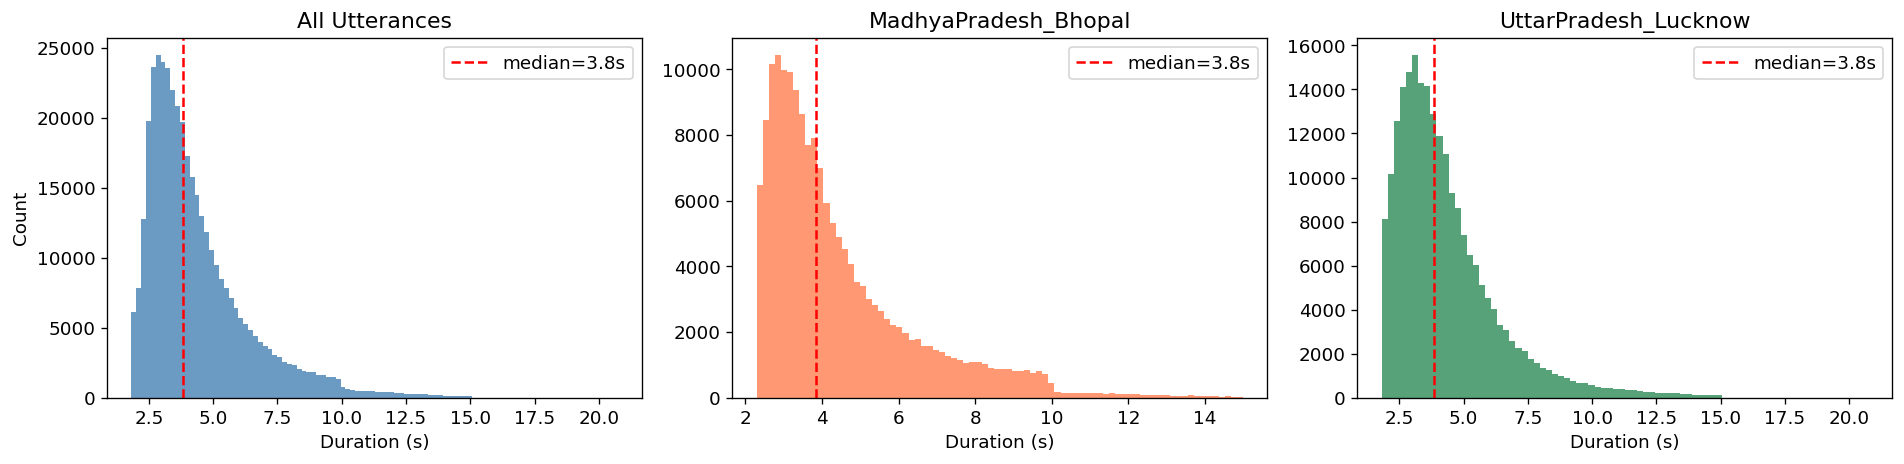

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Overall histogram
axes[0].hist(df["duration"], bins=100, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set_xlabel("Duration (s)")
axes[0].set_ylabel("Count")
axes[0].set_title("All Utterances")
axes[0].axvline(df["duration"].median(), color="red", ls="--", label=f"median={df['duration'].median():.1f}s")
axes[0].legend()

# Per district
for i, district in enumerate(df["district"].unique()):
    if i >= 2:
        break
    subset = df[df["district"] == district]
    axes[i + 1].hist(subset["duration"], bins=80, color=["coral", "seagreen"][i], edgecolor="none", alpha=0.8)
    axes[i + 1].set_xlabel("Duration (s)")
    axes[i + 1].set_title(district)
    axes[i + 1].axvline(subset["duration"].median(), color="red", ls="--",
                         label=f"median={subset['duration'].median():.1f}s")
    axes[i + 1].legend()

plt.tight_layout()
plt.savefig("duration_distributions.png", bbox_inches="tight")
plt.show()

In [5]:
# Duration percentiles
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
pct_values = np.percentile(df["duration"], percentiles)
pct_df = pd.DataFrame({"percentile": percentiles, "duration_s": pct_values.round(3)})
print("Duration percentiles:")
pct_df

Duration percentiles:


,percentile,duration_s
0,1,1.948
1,5,2.304
2,10,2.516
3,25,2.990
4,50,3.836
5,75,5.214
6,90,7.183
7,95,8.660
8,99,11.738


## 3. Speaker Analysis

In [6]:
spk_stats = df.groupby("speaker_id").agg(
    num_utterances=("duration", "count"),
    total_duration=("duration", "sum"),
    mean_duration=("duration", "mean"),
    district=("district", "first"),
    split=("split", "first"),
).reset_index()

print(f"Unique speakers: {len(spk_stats):,}")
print(f"\nUtterances per speaker:")
print(spk_stats["num_utterances"].describe().round(2).to_string())
print(f"\nTotal duration per speaker (s):")
print(spk_stats["total_duration"].describe().round(2).to_string())

Unique speakers: 221,509

Utterances per speaker:
count    221509.00
mean          1.79
std           0.41
min           1.00
25%           2.00
50%           2.00
75%           2.00
max           2.00

Total duration per speaker (s):
count    221509.00
mean          7.88
std           3.01
min           1.82
25%           5.94
50%           7.57
75%           9.64
max          27.93


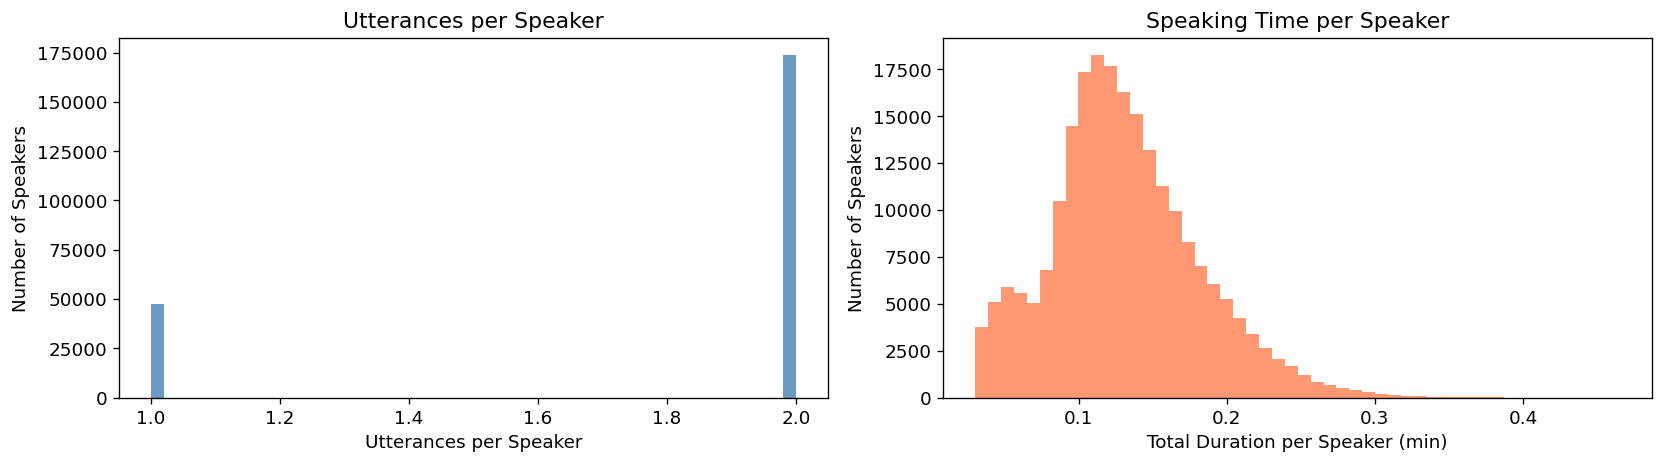

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(spk_stats["num_utterances"], bins=50, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set_xlabel("Utterances per Speaker")
axes[0].set_ylabel("Number of Speakers")
axes[0].set_title("Utterances per Speaker")

axes[1].hist(spk_stats["total_duration"] / 60, bins=50, color="coral", edgecolor="none", alpha=0.8)
axes[1].set_xlabel("Total Duration per Speaker (min)")
axes[1].set_ylabel("Number of Speakers")
axes[1].set_title("Speaking Time per Speaker")

plt.tight_layout()
plt.savefig("speaker_distributions.png", bbox_inches="tight")
plt.show()

In [8]:
# Top 10 speakers by utterance count
top_spk = spk_stats.nlargest(10, "num_utterances")[["speaker_id", "num_utterances", "total_duration", "district", "split"]]
top_spk["total_duration"] = top_spk["total_duration"].round(1)
print("Top 10 speakers by utterance count:")
top_spk

Top 10 speakers by utterance count:


,speaker_id,num_utterances,total_duration,district,split
0,spk_0,2,9.9,MadhyaPradesh_Bhopal,train
1,spk_1,2,5.5,MadhyaPradesh_Bhopal,train
2,spk_10,2,7.3,MadhyaPradesh_Bhopal,test
3,spk_100,2,8.1,MadhyaPradesh_Bhopal,train
4,spk_1000,2,8.4,MadhyaPradesh_Bhopal,train
5,spk_10000,2,4.6,MadhyaPradesh_Bhopal,train
6,spk_100000,2,6.0,MadhyaPradesh_Bhopal,train
7,spk_100001,2,6.6,MadhyaPradesh_Bhopal,train
8,spk_100002,2,9.6,MadhyaPradesh_Bhopal,train
9,spk_100003,2,9.4,MadhyaPradesh_Bhopal,test


## 4. Split Balance

In [9]:
split_summary = df.groupby("split").agg(
    utterances=("duration", "count"),
    speakers=("speaker_id", "nunique"),
    hours=("duration", lambda x: x.sum() / 3600),
    mean_dur=("duration", "mean"),
    median_dur=("duration", "median"),
).round(2)

split_summary["utt_pct"] = (split_summary["utterances"] / split_summary["utterances"].sum() * 100).round(1)
split_summary["spk_pct"] = (split_summary["speakers"] / split_summary["speakers"].sum() * 100).round(1)

print("Split summary:")
split_summary

Split summary:


,utterances,speakers,hours,mean_dur,median_dur,utt_pct,spk_pct
split,,,,,,,
test,39512,22152,48.35,4.41,3.84,10.0,10.0
train,316329,177207,388.04,4.42,3.84,80.0,80.0
val,39587,22150,48.64,4.42,3.83,10.0,10.0


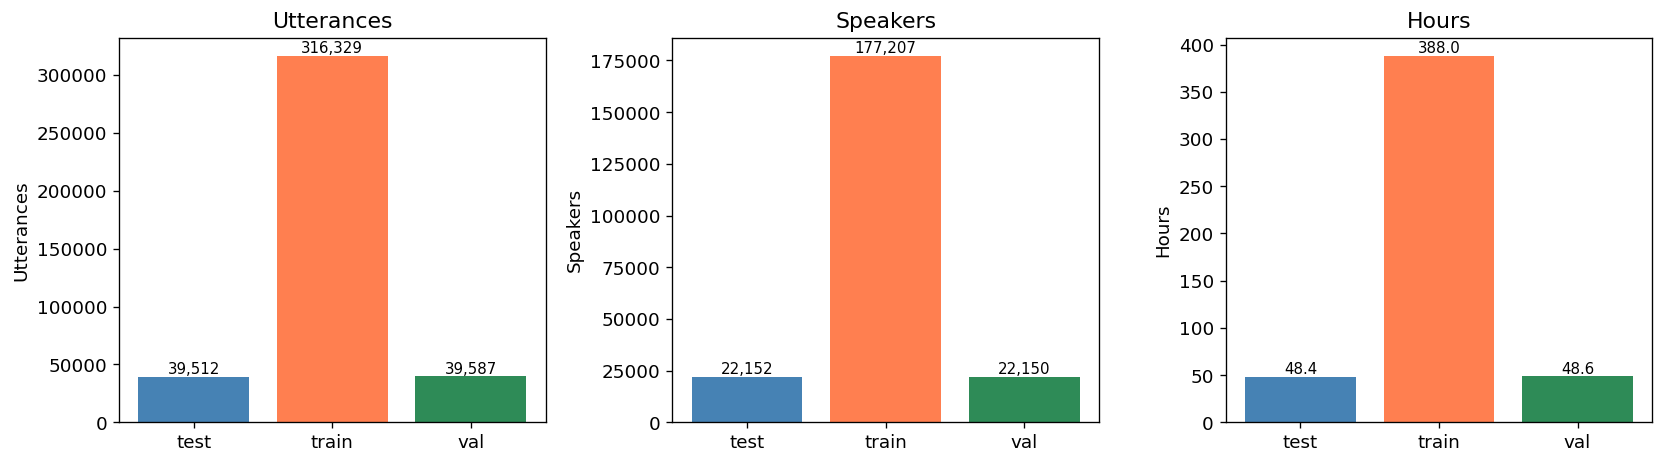

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ["steelblue", "coral", "seagreen"]

for ax, col, title in zip(axes, ["utterances", "speakers", "hours"],
                           ["Utterances", "Speakers", "Hours"]):
    vals = split_summary[col]
    ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(title)
    ax.set_ylabel(title)
    for j, v in enumerate(vals.values):
        label = f"{v:,.0f}" if col != "hours" else f"{v:.1f}"
        ax.text(j, v, label, ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("split_balance.png", bbox_inches="tight")
plt.show()

In [11]:
# Verify no speaker overlap
train_spk = set(df[df["split"] == "train"]["speaker_id"])
val_spk = set(df[df["split"] == "val"]["speaker_id"])
test_spk = set(df[df["split"] == "test"]["speaker_id"])

print(f"Train-Val overlap:  {len(train_spk & val_spk)} speakers")
print(f"Train-Test overlap: {len(train_spk & test_spk)} speakers")
print(f"Val-Test overlap:   {len(val_spk & test_spk)} speakers")
print("\n✓ No speaker leakage" if len(train_spk & val_spk) == 0 and len(train_spk & test_spk) == 0 and len(val_spk & test_spk) == 0 else "✗ SPEAKER LEAKAGE DETECTED")

Train-Val overlap:  0 speakers
Train-Test overlap: 0 speakers
Val-Test overlap:   0 speakers

✓ No speaker leakage


## 5. District Comparison

In [12]:
district_summary = df.groupby("district").agg(
    utterances=("duration", "count"),
    speakers=("speaker_id", "nunique"),
    hours=("duration", lambda x: x.sum() / 3600),
    mean_dur=("duration", "mean"),
    std_dur=("duration", "std"),
    min_dur=("duration", "min"),
    max_dur=("duration", "max"),
).round(3)

print("District comparison:")
district_summary

District comparison:


,utterances,speakers,hours,mean_dur,std_dur,min_dur,max_dur
district,,,,,,,
MadhyaPradesh_Bhopal,173919,173919,217.046,4.493,2.012,2.29,14.995
UttarPradesh_Lucknow,221509,221509,267.988,4.355,2.056,1.82,20.732


/var/folders/4t/b8mb58417k96y50ykz9_qzlr0000gn/T/ipykernel_57434/1523617335.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_district, labels=districts, patch_artist=True)


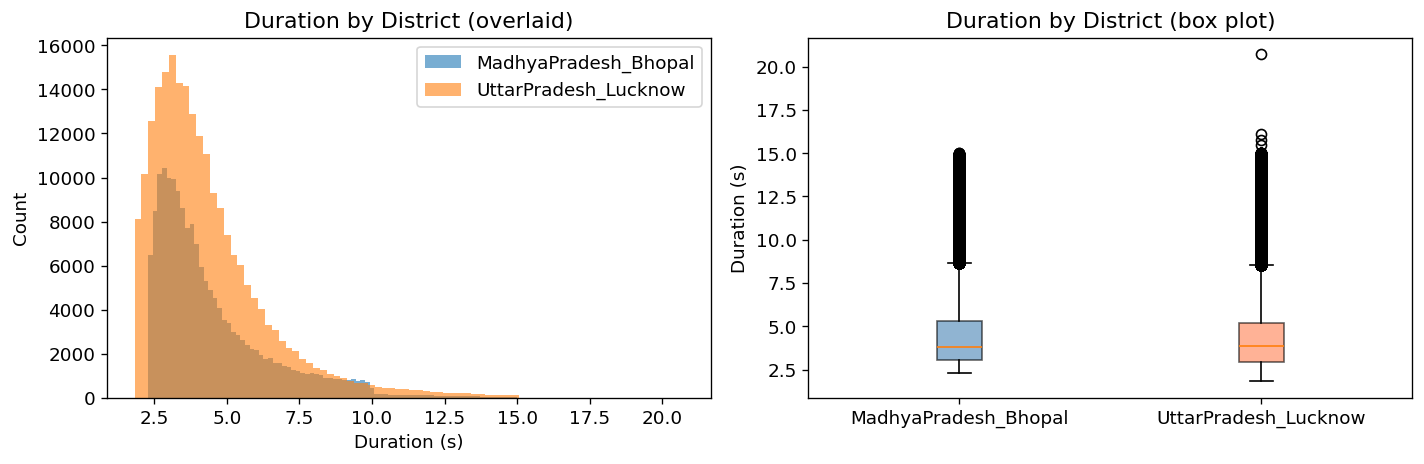

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

districts = df["district"].unique()
for i, d in enumerate(districts):
    subset = df[df["district"] == d]
    axes[0].hist(subset["duration"], bins=80, alpha=0.6, label=d)

axes[0].set_xlabel("Duration (s)")
axes[0].set_ylabel("Count")
axes[0].set_title("Duration by District (overlaid)")
axes[0].legend()

# Box plot
data_by_district = [df[df["district"] == d]["duration"].values for d in districts]
bp = axes[1].boxplot(data_by_district, labels=districts, patch_artist=True)
for patch, color in zip(bp["boxes"], ["steelblue", "coral"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_ylabel("Duration (s)")
axes[1].set_title("Duration by District (box plot)")

plt.tight_layout()
plt.savefig("district_comparison.png", bbox_inches="tight")
plt.show()

## 6. Audio Signal Properties

Sample a random subset of files to measure actual signal properties.

In [14]:
N_SAMPLE = 500
rng = np.random.RandomState(42)
sample_df = df.sample(n=min(N_SAMPLE, len(df)), random_state=42)

signal_stats = []

for _, row in sample_df.iterrows():
    fpath = PROJECT_ROOT / row["audio_path"]
    if not fpath.exists():
        continue
    try:
        info = sf.info(str(fpath))
        y, sr = sf.read(str(fpath), dtype="float32")
        rms = np.sqrt(np.mean(y ** 2))
        peak = np.max(np.abs(y))
        # Zero-crossing rate (proxy for noisiness)
        zcr = np.mean(np.abs(np.diff(np.sign(y))) > 0)
        # Fraction of near-silent frames (< -40 dB)
        frame_len = int(0.025 * sr)
        hop = int(0.010 * sr)
        n_frames = max(1, (len(y) - frame_len) // hop)
        silent_frames = 0
        for fi in range(n_frames):
            frame = y[fi * hop : fi * hop + frame_len]
            frame_rms = np.sqrt(np.mean(frame ** 2)) + 1e-10
            if 20 * np.log10(frame_rms) < -40:
                silent_frames += 1
        silence_ratio = silent_frames / n_frames

        signal_stats.append({
            "audio_path": row["audio_path"],
            "district": row["district"],
            "sample_rate": sr,
            "channels": info.channels,
            "duration_actual": len(y) / sr,
            "rms": rms,
            "peak": peak,
            "rms_db": 20 * np.log10(rms + 1e-10),
            "peak_db": 20 * np.log10(peak + 1e-10),
            "zcr": zcr,
            "silence_ratio": silence_ratio,
            "clipped": peak >= 0.999,
        })
    except Exception as e:
        print(f"Error reading {fpath}: {e}")

sig_df = pd.DataFrame(signal_stats)
print(f"Sampled {len(sig_df)} files for signal analysis")
sig_df.describe().round(4)

Sampled 500 files for signal analysis


,sample_rate,channels,duration_actual,rms,peak,rms_db,peak_db,zcr,silence_ratio
count,500.0,500.0,500.0000,500.0000,500.0,500.0000,500.0000,500.0000,500.0000
mean,16000.0,1.0,4.4037,0.1816,1.0,-15.1545,-0.0002,0.0956,0.0862
std,0.0,0.0,1.8631,0.0491,0.0,2.4902,0.0001,0.0345,0.0866
min,16000.0,1.0,1.8620,0.0553,1.0,-25.1407,-0.0003,0.0243,0.0000
25%,16000.0,1.0,3.1237,0.1423,1.0,-16.9352,-0.0003,0.0722,0.0083
50%,16000.0,1.0,3.9700,0.1786,1.0,-14.9604,-0.0003,0.0899,0.0645
75%,16000.0,1.0,5.1932,0.2154,1.0,-13.3344,-0.0003,0.1131,0.1406
max,16000.0,1.0,13.2100,0.3369,1.0,-9.4510,0.0000,0.3151,0.4299


In [15]:
print(f"Sample rates found: {sig_df['sample_rate'].unique()}")
print(f"Channels found: {sig_df['channels'].unique()}")
print(f"Clipped files: {sig_df['clipped'].sum()} / {len(sig_df)} ({sig_df['clipped'].mean()*100:.1f}%)")
print(f"High silence (>50%): {(sig_df['silence_ratio'] > 0.5).sum()} / {len(sig_df)}")

Sample rates found: [16000]
Channels found: [1]
Clipped files: 500 / 500 (100.0%)
High silence (>50%): 0 / 500


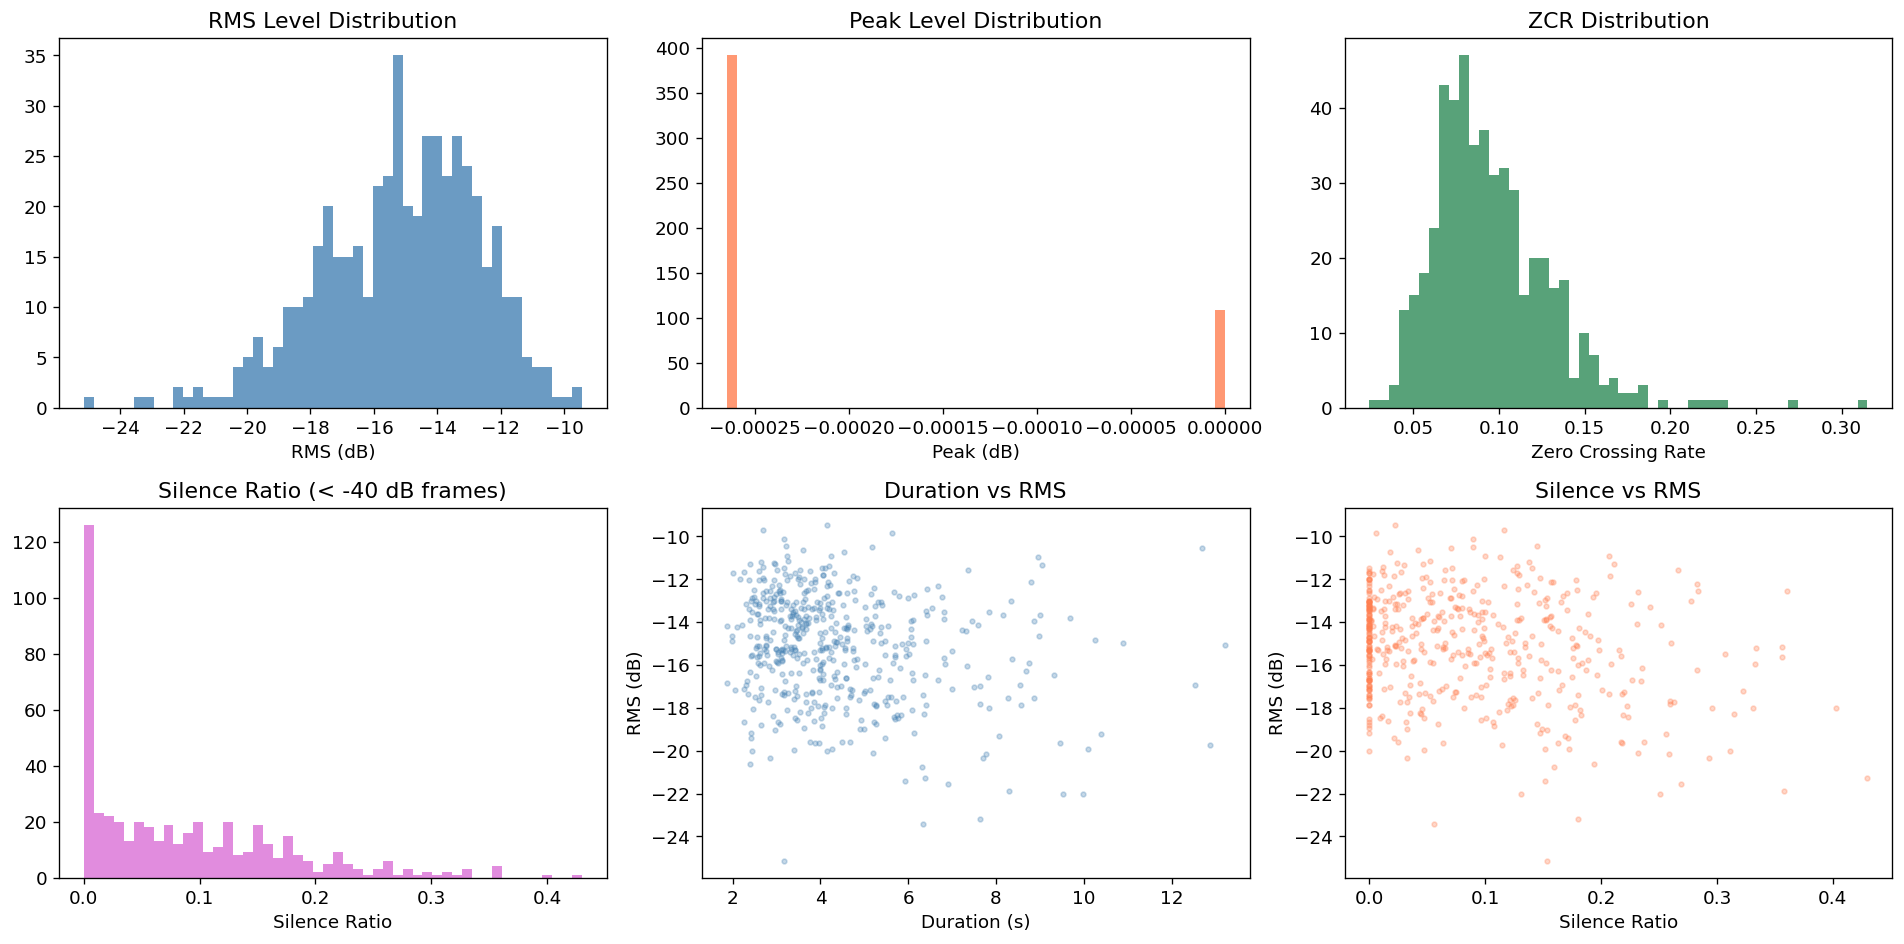

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].hist(sig_df["rms_db"], bins=50, color="steelblue", edgecolor="none", alpha=0.8)
axes[0, 0].set_xlabel("RMS (dB)")
axes[0, 0].set_title("RMS Level Distribution")

axes[0, 1].hist(sig_df["peak_db"], bins=50, color="coral", edgecolor="none", alpha=0.8)
axes[0, 1].set_xlabel("Peak (dB)")
axes[0, 1].set_title("Peak Level Distribution")

axes[0, 2].hist(sig_df["zcr"], bins=50, color="seagreen", edgecolor="none", alpha=0.8)
axes[0, 2].set_xlabel("Zero Crossing Rate")
axes[0, 2].set_title("ZCR Distribution")

axes[1, 0].hist(sig_df["silence_ratio"], bins=50, color="orchid", edgecolor="none", alpha=0.8)
axes[1, 0].set_xlabel("Silence Ratio")
axes[1, 0].set_title("Silence Ratio (< -40 dB frames)")

axes[1, 1].scatter(sig_df["duration_actual"], sig_df["rms_db"], alpha=0.3, s=8, color="steelblue")
axes[1, 1].set_xlabel("Duration (s)")
axes[1, 1].set_ylabel("RMS (dB)")
axes[1, 1].set_title("Duration vs RMS")

axes[1, 2].scatter(sig_df["silence_ratio"], sig_df["rms_db"], alpha=0.3, s=8, color="coral")
axes[1, 2].set_xlabel("Silence Ratio")
axes[1, 2].set_ylabel("RMS (dB)")
axes[1, 2].set_title("Silence vs RMS")

plt.tight_layout()
plt.savefig("signal_properties.png", bbox_inches="tight")
plt.show()

## 7. Waveform & Spectrogram Examples

Pick a few representative samples (short, medium, long) and visualize.

In [17]:
def plot_audio_example(audio_path, title=""):
    """Plot waveform + mel spectrogram + playback widget."""
    fpath = PROJECT_ROOT / audio_path
    y, sr = librosa.load(str(fpath), sr=None, mono=True)
    dur = len(y) / sr

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), gridspec_kw={"height_ratios": [1, 2]})

    # Waveform
    t = np.linspace(0, dur, len(y))
    axes[0].plot(t, y, color="steelblue", linewidth=0.3)
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title(f"{title}   [{dur:.2f}s @ {sr} Hz]")
    axes[0].set_xlim(0, dur)

    # Mel spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80, fmax=8000)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel",
                             ax=axes[1], cmap="magma", fmax=8000)
    axes[1].set_title("Mel Spectrogram")

    plt.tight_layout()
    plt.show()

    display(ipd.Audio(str(fpath)))

/Users/hindy/Desktop/Academics/MIT/MIT MBAn/Spring/GenAI Lab/phronetic-ai-audioinpainting/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


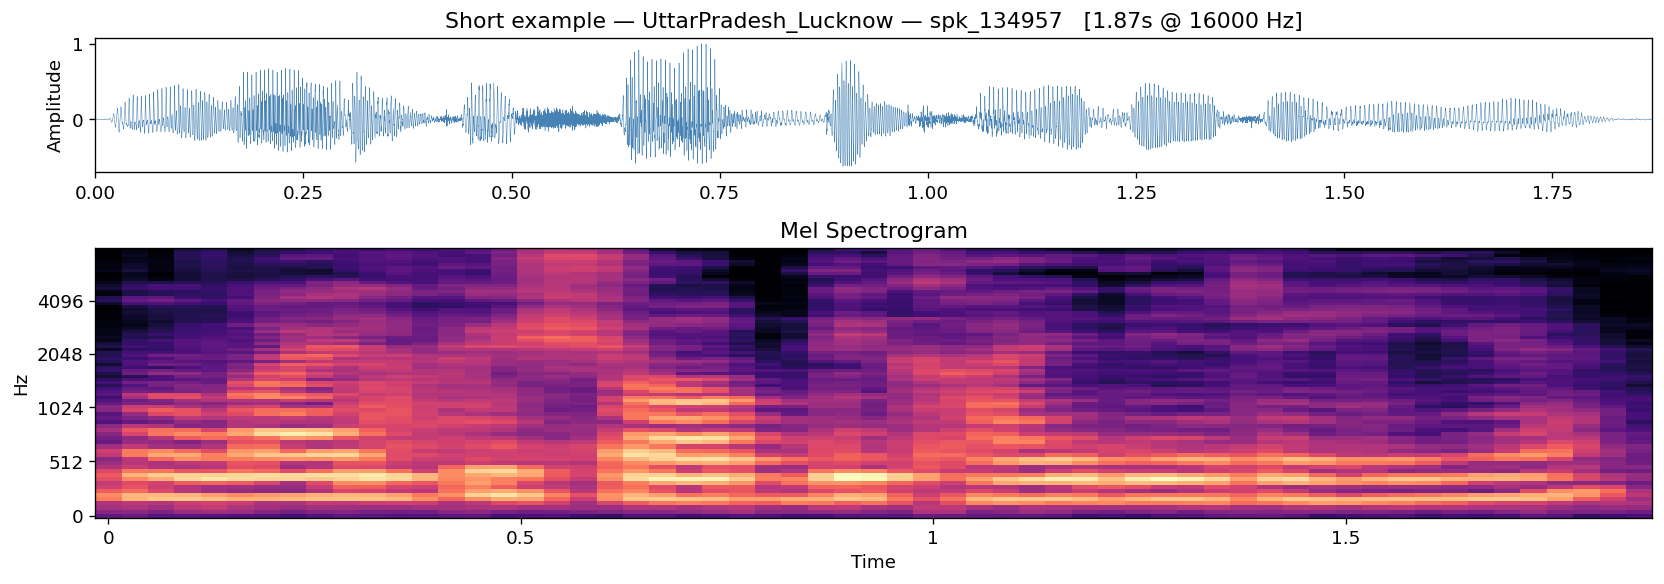

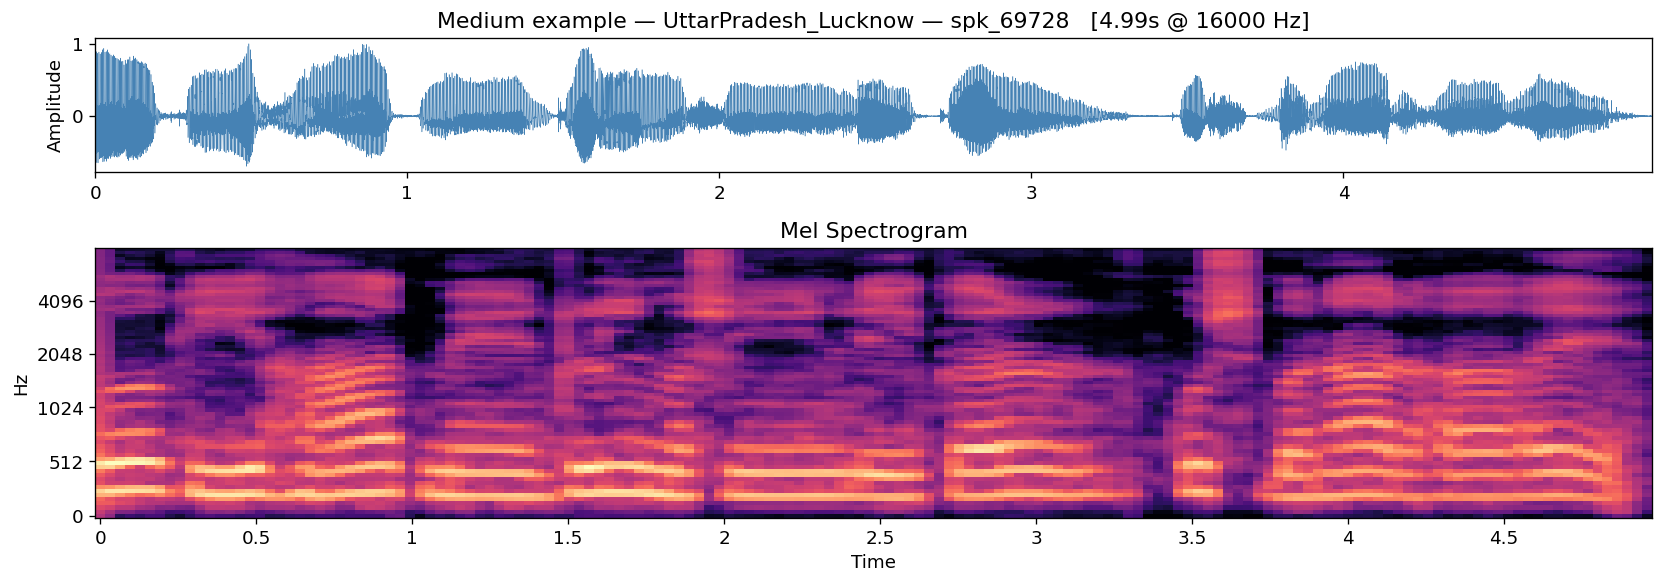

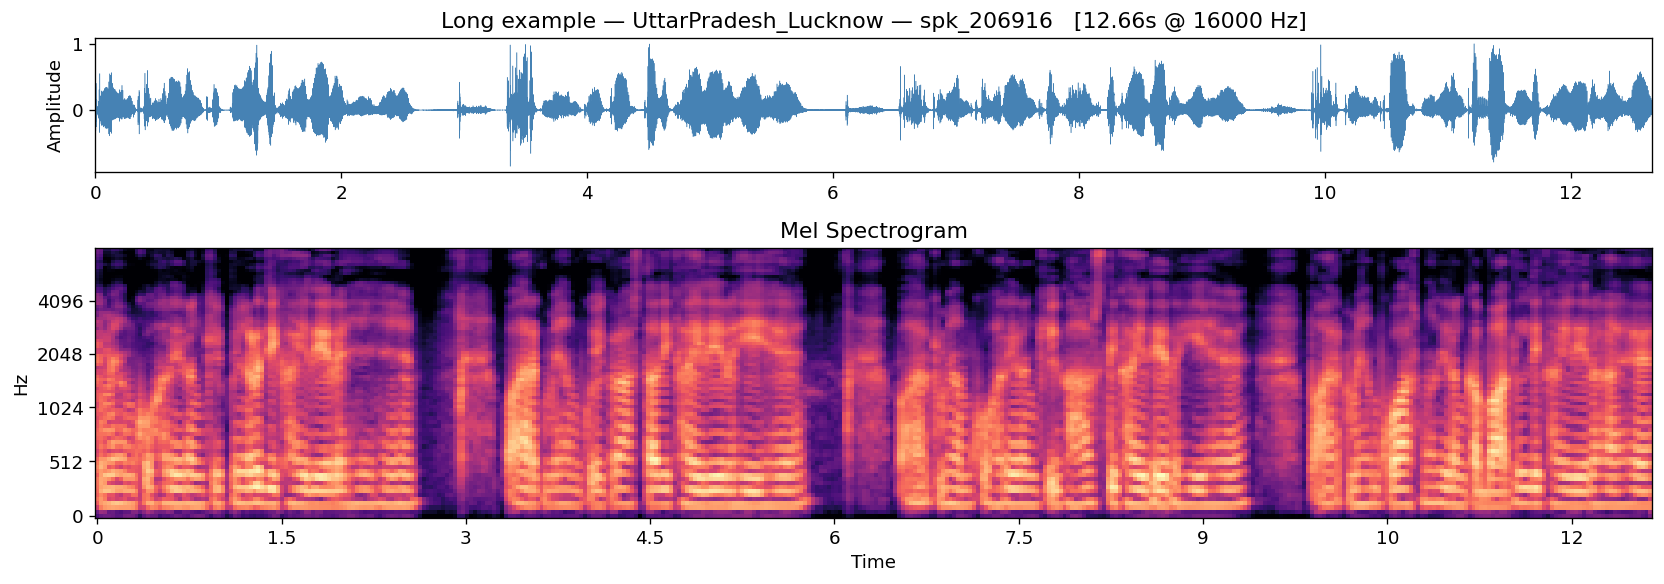

In [18]:
# Pick examples: short (~2s), medium (~5s), long (~15s+)
short = df[(df["duration"] >= 1.5) & (df["duration"] <= 3.0)].sample(1, random_state=42).iloc[0]
medium = df[(df["duration"] >= 4.5) & (df["duration"] <= 6.0)].sample(1, random_state=42).iloc[0]
long = df[(df["duration"] >= 12.0) & (df["duration"] <= 20.0)].sample(1, random_state=42).iloc[0]

for label, row in [("Short example", short), ("Medium example", medium), ("Long example", long)]:
    plot_audio_example(row["audio_path"], title=f"{label} — {row['district']} — {row['speaker_id']}")

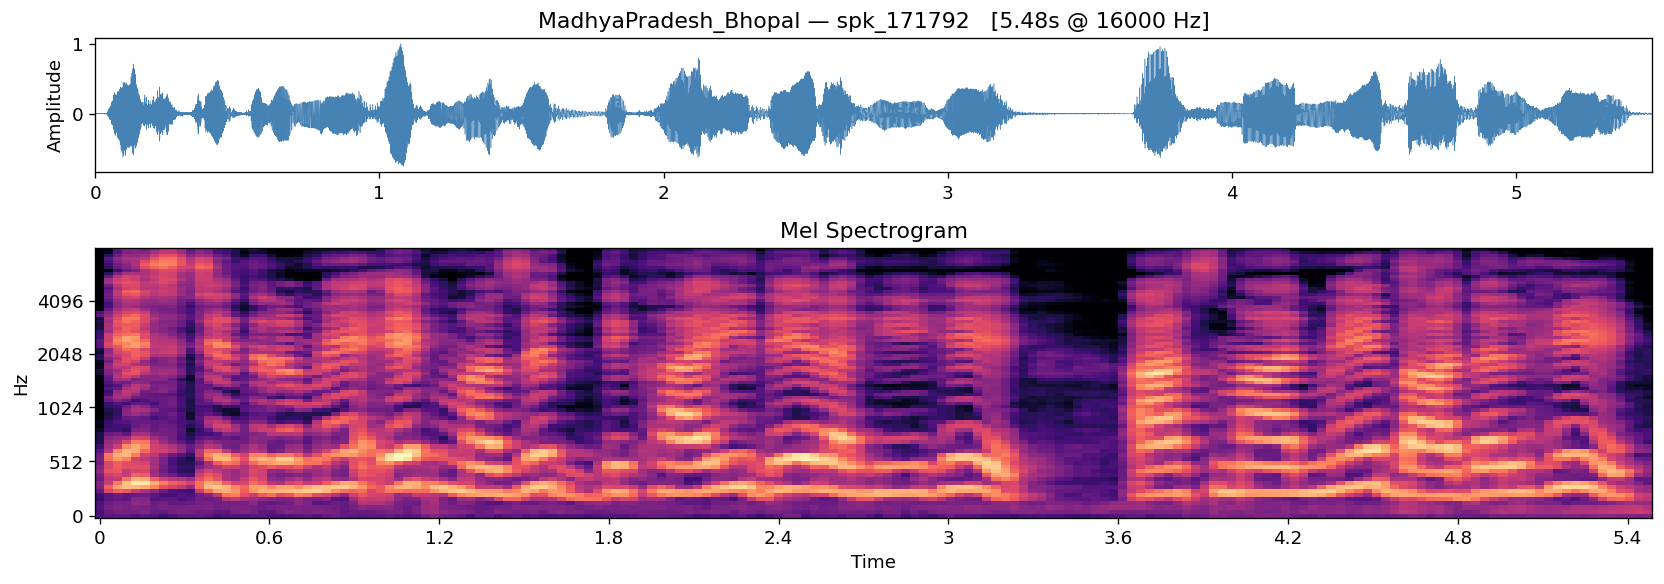

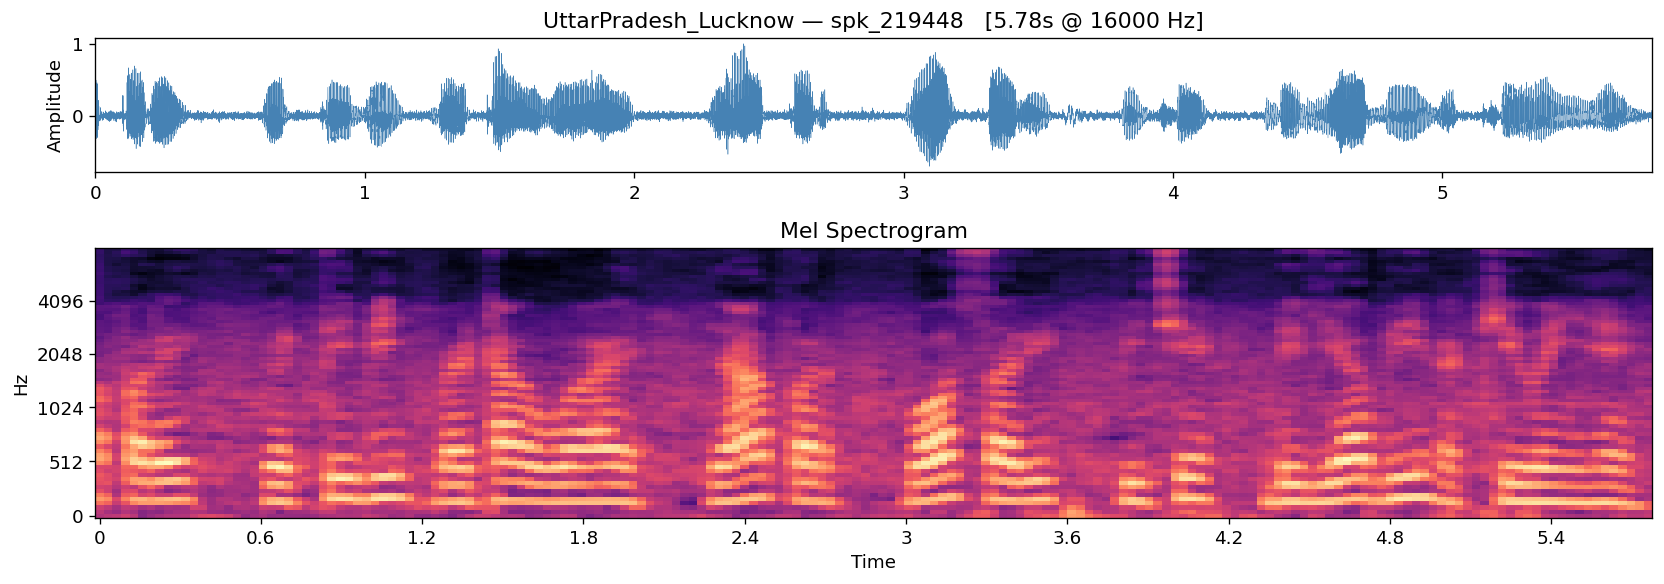

In [19]:
# Compare one sample from each district
for d in df["district"].unique():
    row = df[(df["district"] == d) & (df["duration"] >= 4) & (df["duration"] <= 7)].sample(1, random_state=99).iloc[0]
    plot_audio_example(row["audio_path"], title=f"{d} — {row['speaker_id']}")

## 8. Silence & Clipping Detection

Identify potential quality issues.

In [20]:
# Files with very high silence ratio
high_silence = sig_df[sig_df["silence_ratio"] > 0.6].sort_values("silence_ratio", ascending=False)
print(f"Files with >60% silence: {len(high_silence)} / {len(sig_df)}")
if len(high_silence) > 0:
    print("\nTop 5 most silent files:")
    display(high_silence.head()[["audio_path", "duration_actual", "rms_db", "silence_ratio"]].round(3))

Files with >60% silence: 0 / 500


In [21]:
# Files with clipping
clipped = sig_df[sig_df["clipped"]]
print(f"Clipped files (peak >= -0.01 dB): {len(clipped)} / {len(sig_df)}")
if len(clipped) > 0:
    print("\nClipped files:")
    display(clipped.head()[["audio_path", "peak_db", "rms_db", "duration_actual"]].round(3))

Clipped files (peak >= -0.01 dB): 500 / 500

Clipped files:


,audio_path,peak_db,rms_db,duration_actual
0,data/raw/MadhyaPradesh_Bhopal/MadhyaPradesh_Bh...,-0.0,-16.052,7.330
1,data/raw/MadhyaPradesh_Bhopal/MadhyaPradesh_Bh...,-0.0,-19.598,3.750
2,data/raw/UttarPradesh_Lucknow/UttarPradesh_Luc...,-0.0,-15.963,6.846
3,data/raw/MadhyaPradesh_Bhopal/MadhyaPradesh_Bh...,-0.0,-15.485,3.500
4,data/raw/MadhyaPradesh_Bhopal/MadhyaPradesh_Bh...,-0.0,-13.399,3.320


In [22]:
# If there are high-silence files, visualize one
if len(high_silence) > 0:
    worst = high_silence.iloc[0]
    plot_audio_example(worst["audio_path"], title=f"High silence ({worst['silence_ratio']:.0%})")

## 9. Summary

In [23]:
print("=" * 60)
print("AUDIO EDA SUMMARY")
print("=" * 60)
print(f"Total utterances:        {len(df):>10,}")
print(f"Total hours:             {total_hours:>10.1f}")
print(f"Unique speakers:         {df['speaker_id'].nunique():>10,}")
print(f"Districts:               {', '.join(df['district'].unique())}")
print(f"")
print(f"Duration range:          {df['duration'].min():.2f}s — {df['duration'].max():.2f}s")
print(f"Duration mean/median:    {df['duration'].mean():.2f}s / {df['duration'].median():.2f}s")
print(f"")
print(f"Sample rates:            {sig_df['sample_rate'].unique()}")
print(f"Channels:                {sig_df['channels'].unique()}")
print(f"RMS range (dB):          {sig_df['rms_db'].min():.1f} — {sig_df['rms_db'].max():.1f}")
print(f"Clipped files (sampled): {sig_df['clipped'].sum()} / {len(sig_df)} ({sig_df['clipped'].mean()*100:.1f}%)")
print(f"High silence (>50%):     {(sig_df['silence_ratio'] > 0.5).sum()} / {len(sig_df)}")
print(f"")
print(f"Speaker overlap across splits: None")
print(f"Split ratio (utt):       train={len(dfs.get('train',[])):,}  val={len(dfs.get('val',[])):,}  test={len(dfs.get('test',[])):,}")
print("=" * 60)

AUDIO EDA SUMMARY
Total utterances:           395,428
Total hours:                  485.0
Unique speakers:            221,509
Districts:               MadhyaPradesh_Bhopal, UttarPradesh_Lucknow

Duration range:          1.82s — 20.73s
Duration mean/median:    4.42s / 3.84s

Sample rates:            [16000]
Channels:                [1]
RMS range (dB):          -25.1 — -9.5
Clipped files (sampled): 500 / 500 (100.0%)
High silence (>50%):     0 / 500

Speaker overlap across splits: None
Split ratio (utt):       train=316,329  val=39,587  test=39,512
